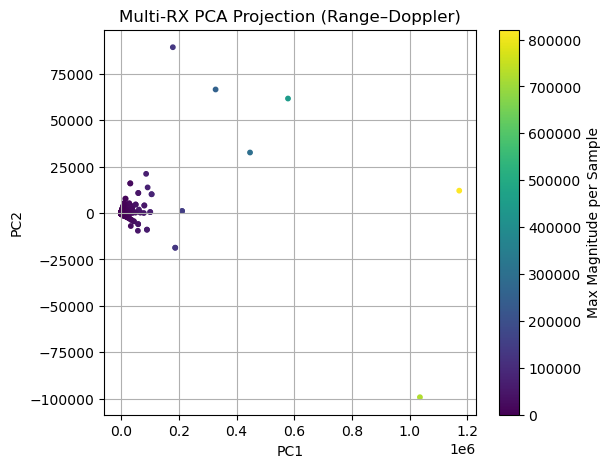

In [23]:
import scipy.io
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

def convert_to_data_frame(matlabFilePath, variableName):
    matData = scipy.io.loadmat(matlabFilePath)
    xdata = matData[variableName]

    df = pd.DataFrame(xdata)
    df = df.transpose()
    df.columns = ['RX0', 'RX1', 'RX2', 'RX3']
    return df

# Parameters
numADCSamples = 256
numChirps = 1024
Nfft_range = 256
Nfft_doppler = 128
Fs = 10e6          # sampling rate (Hz)
c = 3e8            # speed of light (m/s)
slope = 29.982e12  # chirp slope (Hz/s)
fc = 77e9          # carrier frequency (Hz)
chirpPeriod = 40e-3
chirpRate = 1 / chirpPeriod

def range_doppler_multi_rx(df):
    dopplerFFTs = []
    
    # Process each RX channel
    for rx in df.columns:
        rx_series = df[rx]
        rx_matrix = rx_series.values.reshape(numChirps, numADCSamples)
        df_rx = pd.DataFrame(rx_matrix)
        
        # Range FFT
        window_range = np.hamming(numADCSamples)
        df_rx = df_rx.mul(window_range, axis=1)
        df_rx = df_rx.sub(df_rx.mean(axis=1), axis=0)
        
        rangeFFT = np.fft.fft(df_rx.values, n=Nfft_range, axis=1)
        rangeFFT = np.abs(rangeFFT[:, :Nfft_range//2])
        
        # Doppler FFT
        window_doppler = np.hamming(numChirps)
        rangeFFT_win = rangeFFT * window_doppler[:, np.newaxis]
        
        dopplerFFT = np.fft.fftshift(
            np.fft.fft(rangeFFT_win, n=Nfft_doppler, axis=0),
            axes=0
        )
        dopplerFFT = np.abs(dopplerFFT)
        
        dopplerFFTs.append(dopplerFFT)
    
    #Stack all RX channels together
    dopplerFFTs = np.stack(dopplerFFTs, axis=-1)
    
    # Range and velocity axes
    freqAxis_range = np.arange(Nfft_range//2) * (Fs / Nfft_range)
    dopplerAxis = np.linspace(-chirpRate/2, chirpRate/2, Nfft_doppler)
    lambda_c = c / fc
    velocityAxis = (lambda_c / 2) * dopplerAxis
    
    X = dopplerFFTs.reshape(-1, dopplerFFTs.shape[-1])  # [samples, numRx]
    
    pca = PCA(n_components=2)
    X_pca = pca.fit_transform(X)
    
    # Plot PCA projection
    plt.figure(figsize=(6,5))
    plt.scatter(X_pca[:,0], X_pca[:,1], c=np.max(X, axis=1), cmap='viridis', s=10)
    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.title("Multi-RX PCA Projection (Range–Doppler)")
    plt.colorbar(label="Max Magnitude per Sample")
    plt.grid(True)
    plt.show()

adcData = convert_to_data_frame(r'C:\Users\kavin\20250110\_5\_1\adc_data.mat', 'ans')
range_doppler_multi_rx(adcData)